Determinación de $\mathbf{X}_0$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.neural_network import MLPRegressor
import warnings
from IPython.display import display, Math


path = '/content/POWER_Point_Hourly_20120101_20180101_004d80N_075d68W_LST (1).csv'
X0 = pd.read_csv(path, skiprows=13)
X0 = X0.iloc[:, -5:]
columnas = ['temperatura', 'humedad', 'precipitacion', 'velocidad', 'direccion']
X0.columns = columnas


In [ ]:
print((X0.max()[1] - X0.min()[1])*(-0.1806)*np.array([ 0.68828999, -0.19954108, 0.69545738, 0.05271887]))
(X0.max()[1] - X0.min()[1])*0.7829 + X0.min()[1]

[-7.76658716  2.2515992  -7.84746318 -0.59487382]


/tmp/ipykernel_2168/2189545334.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print((X0.max()[1] - X0.min()[1])*(-0.1806)*np.array([ 0.68828999, -0.19954108, 0.69545738, 0.05271887]))
/tmp/ipykernel_2168/2189545334.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (X0.max()[1] - X0.min()[1])*0.7829 + X0.min()[1]


np.float64(86.435592)

In [ ]:
X0.std()[0]*np.array([-3.3536, 0.438, -0.3876, 1.5432])
0.7829*

In [ ]:
X0.mean()[0]

$Limite\_superior = Q_3 + 1.5IQR$

$Limite\_inferior = Q_1 - 1.5IQR$

$IQR = Q_3 - Q_1$

$Si \text{ } X_0 \geq Limite\_inferior \text{ } Y \text{} X_0\leq Limite\_superior$

$\quad \text{Eliminar correspondiente fila } X_0$

$\text{Fin del Si}$

In [2]:
# Aplicar filtro IQR individualmente a cada señal
Q1 = X0.quantile(0.25)
Q3 = X0.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
Mascara = (X0>= limite_inferior) & (X0 <= limite_superior)
X1 = X0[Mascara.all(axis=1)]

print(X0.shape[0] - X1.shape[0])
X1.to_csv('Data_real_fitrada.csv')
print("archivo guardado")

5196
archivo guardado


$Temperatura: \mathcal{N}_1(x_1) = \frac{x_1 - \bar{x}_1}{\sigma_{x_1}}$

$Humedad \text{ } Relativa:\mathcal{N}_2(x_2) = \frac{x_2 - \min(x_2)}{\max(x_2) - \min(x_2)}$

$Precipitación: P_{x_3} = log(x_3 + 1)$

$\quad\quad\quad\quad\quad\quad\quad \mathcal{N}_3(x_3) = \frac{P_{x_{3}} - \overline{P}_{x_{3}}}{\sigma_{P_{x_3}}}$

$Velocidad \text{ } del \text{ } tiempo: P_{x_4} = log(x_4 + 1)$

$\quad\quad\quad\quad\quad\quad\quad \mathcal{N}_4(x_4) = \frac{P_{x_{4}} - \overline{P}_{x_{4}}}{\sigma_{P_{x_4}}}$

$Dirección \text{ } del \text{ } tiempo: \mathcal{N}_5(x_5) = \frac{x_5 - \min(x_5)}{\max(x_5) - \min(x_5)}$$

In [3]:

normalization_pipeline = ColumnTransformer(transformers=[
    ('temperatura', StandardScaler(), ['temperatura']),
    ('humedad', MinMaxScaler(), ['humedad']),
    ('precipitacion', Pipeline([
        ('log', FunctionTransformer(np.log1p, validate=True)),
        ('zscore', StandardScaler())]), ['precipitacion']),
    ('velocidad', Pipeline([
        ('log', FunctionTransformer(np.log1p, validate=True)),
        ('zscore', StandardScaler())]), ['velocidad']),
    ('direccion', MinMaxScaler(), ['direccion'])
    ])

# Aplicar la normalización
X2 = normalization_pipeline.fit_transform(X1)
X2= pd.DataFrame(X2)
X2.columns = columnas
X2.to_csv('Data_Normalizada.csv')

In [ ]:
X2

,temperatura,humedad,precipitacion,velocidad,direccion
0,-0.924698,1.000000,-1.295739,2.120851,0.427655
1,-1.059316,1.000000,-1.295739,2.120851,0.439922
2,-1.193934,1.000000,-1.284840,2.120851,0.439922
3,-1.304993,1.000000,-1.274046,2.359460,0.438249
4,-1.429515,1.000000,-1.274046,2.476565,0.435461
...,...,...,...,...,...
47431,-0.497286,0.961235,0.826934,0.966494,0.752718
47432,-0.604980,0.969458,0.803763,1.235354,0.752718
47433,-0.662193,0.960899,0.812093,1.751364,0.737385
47434,-0.709309,0.953180,0.895240,1.937896,0.686646


$\hat{\mathbf{X}}_2 ← \mathbf{X}_2[\vartheta]$

$\hat{\mathbf{Y}}_2 ← \mathbf{X}_2[\vartheta^c]$

$\mathbf{Z} ← \mathbf{PCA}(\hat{\mathbf{X}}_2)$

$\rho_i ← Corr(\mathbf{Z}_i,\hat{\mathbf{Y}}_2)$

$i^* ← \arg\max_{i} \, \lvert \rho_i \rvert$

$\text{sujeto a:} \quad \lvert \rho_i \rvert > \beta$

$\mathbf{X}_{sel} ← \mathbf{X}_2[i^*]$

$\mathbf{Z}_{i^*} ← \mathbf{Z}[i^*]$


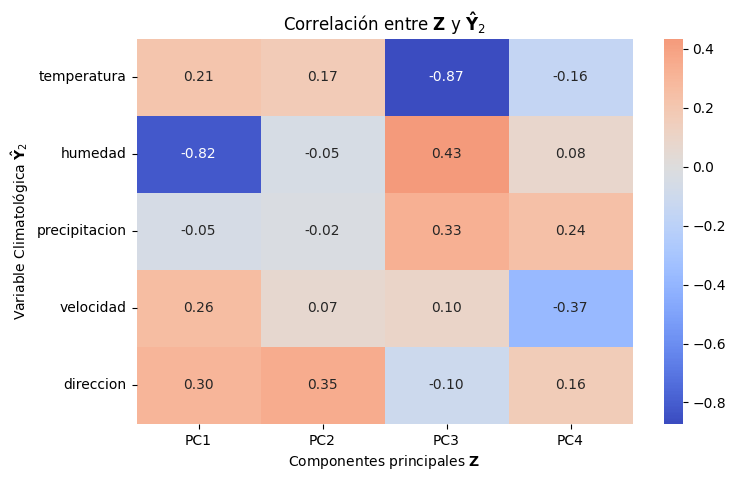

[{'X_sel': 'temperatura',
  'Zi': ['PC3'],
  'ro_i': [-0.8720064760062438],
  'Vector_Ziopt':             PC3
  0      0.467278
  1      0.462179
  2      0.462050
  3      0.487545
  4      0.500937
  ...         ...
  47431  0.151406
  47432  0.187196
  47433  0.239646
  47434  0.272266
  47435  0.289319
  
  [47436 rows x 1 columns],
  'W': array([[ 0.90341172],
         [-0.01184082],
         [ 0.10446827],
         [-0.41568431]])},
 {'X_sel': 'humedad',
  'Zi': ['PC1'],
  'ro_i': [-0.8184673616632256],
  'Vector_Ziopt':             PC1
  0      1.093119
  1      1.001110
  2      0.906279
  3      0.993538
  4      0.989125
  ...         ...
  47431  0.178073
  47432  0.295552
  47433  0.612566
  47434  0.690595
  47435  0.451453
  
  [47436 rows x 1 columns],
  'W': array([[ 0.68828999],
         [-0.19954108],
         [ 0.69545738],
         [ 0.05271887]])}]

In [4]:
correlaciones_lista = []
columnas_pca = ['PC1', 'PC2', 'PC3', 'PC4']
resultados = []
beta = 0.7
for i, j in enumerate(X2.columns):
  X2_hat = X2.drop(columns=[j])
  Y2_hat = X2[j]
  pca = PCA()
  Z = pca.fit_transform(X2_hat)
  Z = pd.DataFrame(Z)
  Z.columns = columnas_pca
  Correlaciones_Z = Z.corrwith(Y2_hat)
  correlaciones_lista.append(Correlaciones_Z)
  W = pca.components_.T
  iopt = Correlaciones_Z.abs() > beta
  if iopt.any():
    ro_i = Correlaciones_Z[iopt]
    resultados.append({"X_sel": j,
                     "Zi": ro_i.index.tolist(),
                     "ro_i": ro_i.values.tolist(),
                     "Vector_Ziopt": Z[ro_i.index.tolist()],
                     "W": W[:,iopt]})

resultados_corr = pd.DataFrame(correlaciones_lista, index=X2.columns)
plt.figure(figsize=(8, 5))

sns.heatmap(resultados_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title(r"Correlación entre $\mathbf{Z}$ y $\mathbf{\hat{Y}}_2$")
plt.xlabel(r"Componentes principales $\mathbf{Z}$")
plt.ylabel(r"Variable Climatológica $\mathbf{\hat{Y}}_2$")

plt.show()
resultados

**Modelo caso temperatura**

$\mathbf{X}_{Train} \sim \text{Muestreo aleatorio de } \mathbf{Z}_{i^*}$

$\mathbf{X}_{Train}| ← 0.8\,|\mathbf{Z}_{i^*}|$

$\mathbf{X}_{Test} ← \mathbf{Z}_{i^*} \setminus \mathbf{X}_{Train}$

$\mathbf{Y}_{Train} \sim \text{Muestreo aleatorio de } \mathbf{X}_{sel}$

$\mathbf{Y}_{Train}| ← 0.8\,|\mathbf{X}_{sel}|$

$\mathbf{Y}_{Test} ← \mathbf{X}_{sel} \setminus \mathbf{Y}_{Train}$

In [ ]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(resultados[0]['Vector_Ziopt'],
                                                    X2[resultados[0]['X_sel']],
                                                    test_size=0.2,
                                                    random_state=42)

$K(x_i, x) = x_i^{\top} x$

$H ← \{C, \varepsilon\}$

$f_q^{(h)} = \mathrm{SVR}\big(\mathbf{X}_{Train} \setminus \mathbf{X}_q, \mathbf{Y}_{Train} \setminus \mathbf{Y}_q, h\big)$

In [ ]:

H = {'C': [0.01, 0.1, 0.5, 1, 20, 50, 100], 'epsilon': [0.01, 0.1, 0.5, 1]}
Kx = SVR(kernel='linear')
H_permutation = GridSearchCV(
    estimator=Kx,
    param_grid={'C': H['C'], 'epsilon': H['epsilon']},
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
    )

# Entrenar GridSearchCV con los datos de entrenamiento
H_permutation.fit(X_Train, Y_Train)



GridSearchCV(cv=5, estimator=SVR(kernel='linear'), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 0.5, 1, 20, 50, 100],
                         'epsilon': [0.01, 0.1, 0.5, 1]},
             scoring='neg_mean_squared_error')

$h^* = \arg\min_{h \in H} e(h)$

$\hat{\mathbf{Y}}_{Test} ← f^{(h^*)}(\mathbf{X}_{Test})$

$RMSE ← \sqrt{\frac{(\mathbf{Y}_{Test} - \hat{\mathbf{Y}}_{Test})^\top(\mathbf{Y}_{Test} - \hat{\mathbf{Y}}_{Test})}{n}}$

$R^2 ← 1 - \left(\frac{RMSE}{\sigma_{\mathbf{Y}_{Test}}}\right)^2$

$ρ(\hat{\mathbf{Y}}_{Test}, \mathbf{Y}_{Test}) ← \frac{COV(\hat{\mathbf{Y}}_{Test}, \mathbf{Y}_{Test})}{σ_{\hat{\mathbf{Y}}_{Test}}σ_{\mathbf{Y}_{Test}}}$



In [ ]:
H_opt = H_permutation.best_params_
fhopt = H_permutation.best_estimator_
# Evaluar el mejor modelo lineal en el conjunto de prueba
Y_Test_hat = fhopt.predict(X_Test)
RMSE = np.sqrt(mean_squared_error(Y_Test, Y_Test_hat))
r2 = r2_score(Y_Test, Y_Test_hat)
ro = np.corrcoef(Y_Test, Y_Test_hat)[0, 1]

display(Math(r"RMSE = \pm{:.4f}".format(RMSE)))
display(Math(r"R^2 = {:.4f}".format(r2)))
display(Math(r"\rho(\hat{{Y}}_{{Test}}, Y_{{Test}}) = {:.4f}".format(ro)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Modelo**

$\hat{\mathbf{X}}_1 = -3.7123\mathbf{Z}_{new} + 0.0058$

**Modelo desnormalizado**

$\hat{X}_{Temperatura} = -9.9653X_{Humedad_N} + 0.1306X_{Precipitacion_N} -1.1524X_{Velocidad_N} + 4.5853X_{Direccion_N} + 16.1349$

In [ ]:
a = fhopt.coef_[0][0]
b = fhopt.intercept_[0]
print('Pendiente:', a, 'Intercepto:', b)

-3.7122819049216957 0.005770679782082827


**Construcción del modelo desnormalizado caso temperatura ambiente tabla 3**



In [9]:
#a = -3.7122819049216957
#b = 0.005770679782082827
Coeficientes_Variables_Norm = X1.std().iloc[0] * a *resultados[0]['W'].reshape(-1)
Coeficiente_Intercepto_Norm = X1.std().iloc[0] * b +  X1.mean().iloc[0]
print('Coeficiente modelo desnormalizado:', Coeficientes_Variables_Norm)
print('Coeficiente intercepción modelo des:', Coeficiente_Intercepto_Norm)

Coeficiente modelo desnormalizado: [-9.96525541  0.13061248 -1.15235721  4.58528512]
Coeficiente intercepción modelo des: 16.1347690826648


**Red Neuronal: Temperatura**

In [ ]:
# Define los parámetros de búsqueda
H = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [500, 1000]
    }
MLP = MLPRegressor(random_state=42, early_stopping=True)
funcion_perdida = make_scorer(mean_squared_error, greater_is_better=False)
H_opt = GridSearchCV(MLP, H, cv=5, scoring=funcion_perdida, n_jobs=-1)
H_opt.fit(X_Train, Y_Train)
MLP_opt = H_opt.best_estimator_


$\hat{\mathbf{Y}}_{Test} ← MLP^{(h^*)}(\mathbf{X}_{Test})$

$RMSE ← \sqrt{\frac{(\mathbf{Y}_{Test} - \hat{\mathbf{Y}}_{Test})^\top(\mathbf{Y}_{Test} - \hat{\mathbf{Y}}_{Test})}{n}}$

$R^2 ← 1 - \left(\frac{RMSE}{\sigma_{\mathbf{Y}_{Test}}}\right)^2$

$ρ(\hat{\mathbf{Y}}_{Test}, \mathbf{Y}_{Test}) ← \frac{COV(\hat{\mathbf{Y}}_{Test}, \mathbf{Y}_{Test})}{σ_{\hat{\mathbf{Y}}_{Test}}σ_{\mathbf{Y}_{Test}}}$

In [ ]:
# Evalua el mejor MLP
Y_Test_hat = MLP_opt.predict(X_Test)
RMSE = np.sqrt(mean_squared_error(Y_Test, Y_Test_hat))
r2 = r2_score(Y_Test, Y_Test_hat)
ro = np.corrcoef(Y_Test, Y_Test_hat)[0, 1]

display(Math(r"RMSE = \pm{:.4f}".format(RMSE)))
display(Math(r"R^2 = {:.4f}".format(r2)))
display(Math(r"\rho(\hat{{Y}}_{{Test}}, Y_{{Test}}) = {:.4f}".format(ro)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Modelo Caso Humedad: SVR**

In [ ]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(resultados[1]['Vector_Ziopt'],
                                                    X2[resultados[1]['X_sel']],
                                                    test_size=0.2,
                                                    random_state=42)

In [ ]:
H = {'C': [0.01, 0.1, 0.5, 1, 20, 50, 100], 'epsilon': [0.01, 0.1, 0.5, 1]}
Kx = SVR(kernel='linear')
H_permutation = GridSearchCV(
    estimator=Kx,
    param_grid={'C': H['C'], 'epsilon': H['epsilon']},
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    n_jobs=-1
    )

# Entrenar GridSearchCV con los datos de entrenamiento
H_permutation.fit(X_Train, Y_Train)

GridSearchCV(cv=5, estimator=SVR(kernel='linear'), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 0.5, 1, 20, 50, 100],
                         'epsilon': [0.01, 0.1, 0.5, 1]},
             scoring='neg_mean_squared_error')

In [ ]:
H_opt = H_permutation.best_params_
fhopt = H_permutation.best_estimator_
# Evaluar el mejor modelo lineal en el conjunto de prueba
Y_Test_hat = fhopt.predict(X_Test)
RMSE = np.sqrt(mean_squared_error(Y_Test, Y_Test_hat))
r2 = r2_score(Y_Test, Y_Test_hat)
ro = np.corrcoef(Y_Test, Y_Test_hat)[0, 1]

display(Math(r"RMSE = \pm{:.4f}".format(RMSE)))
display(Math(r"R^2 = {:.4f}".format(r2)))
display(Math(r"\rho(\hat{{Y}}_{{Test}}, Y_{{Test}}) = {:.4f}".format(ro)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Modelo**

$\hat{\mathbf{X}}_2 = -0.18\mathbf{Z}_{new} + 0.7829$

$\hat{X}_{Humedad} = -7.4073X_{Temperatura_N} + 2.1475X_{Precipitacion_N} -7.4845X_{Velocidad_N} - 0.5674X_{Direccion_N} + 87.063$

In [ ]:
a = fhopt.coef_[0][0]
b = fhopt.intercept_[0]
print('Pendiente:', a, 'Intercepto:', b)

-0.18055441945794581 0.7829304295221993


**Construcción del modelo desnormalizado caso humedad relativa ver tabla 3**

In [10]:
#a = -0.18055441945794581
#b = 0.7829304295221993
Coeficientes_Variables_Norm = (X1.max().iloc[1] - X1.min().iloc[1]) * a * resultados[1]['W'].reshape(-1)
Coeficiente_Intercepto_Norm = (X1.max().iloc[1] - X1.min().iloc[1]) * b +  X1.min().iloc[1]
print('Coeficiente modelo desnormalizado:', Coeficientes_Variables_Norm)
print('Coeficiente intercepción modelo des:', Coeficiente_Intercepto_Norm)

Coeficiente modelo desnormalizado: [-7.40547569  2.14690991 -7.48259141 -0.56721483]
Coeficiente intercepción modelo des: 87.06482429522785


In [ ]:
H_opt = H_permutation.best_params_
H_opt

{'C': 0.01, 'epsilon': 0.1}

**Red neuronal caso Humedad**

In [ ]:
# Define los parámetros de búsqueda
H = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [500, 1000]
    }
MLP = MLPRegressor(random_state=42, early_stopping=True)
funcion_perdida = make_scorer(mean_squared_error, greater_is_better=False)
H_opt = GridSearchCV(MLP, H, cv=5, scoring=funcion_perdida, n_jobs=-1)
H_opt.fit(X_Train, Y_Train)
MLP_opt = H_opt.best_estimator_

In [ ]:
# Evalua el mejor MLP
Y_Test_hat = MLP_opt.predict(X_Test)
RMSE = np.sqrt(mean_squared_error(Y_Test, Y_Test_hat))
r2 = r2_score(Y_Test, Y_Test_hat)
ro = np.corrcoef(Y_Test, Y_Test_hat)[0, 1]

display(Math(r"RMSE = \pm{:.4f}".format(RMSE)))
display(Math(r"R^2 = {:.4f}".format(r2)))
display(Math(r"\rho(\hat{{Y}}_{{Test}}, Y_{{Test}}) = {:.4f}".format(ro)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>